In [1]:
import pickle

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from pansat.products.satellite.cloud_sat import l2b_cldclass, l2b_cldclass_lidar
import xarray as xr

In [2]:
lon_edges = np.arange(-180, 181)
lat_edges = np.arange(-90, 91)

# All 2010 data

In [3]:
with open('2B-CLDCLASS_vs_2B-CLDCLASS-LIDAR_maps.pickle', 'rb') as handle:
    arrays = pickle.load(handle)

In [4]:
average_ro = np.divide(
    arrays['hits_ro'],
    arrays['counts_ro'],
    np.full((360, 180), np.nan),
    where=arrays['counts_ro'] > 0
)

average_lr = np.divide(
    arrays['hits_lr'],
    arrays['counts_lr'],
    np.full((360, 180), np.nan),
    where=arrays['counts_lr'] > 0
)

average_lrq = np.divide(
    arrays['hits_lrq'],
    arrays['counts_lrq'],
    np.full((360, 180), np.nan),
    where=arrays['counts_lrq'] > 0
)

In [5]:
print("All values from the height bins are equal between the two products?", all(arrays['heights_lr']))

All values from the height bins are equal between the two products? True


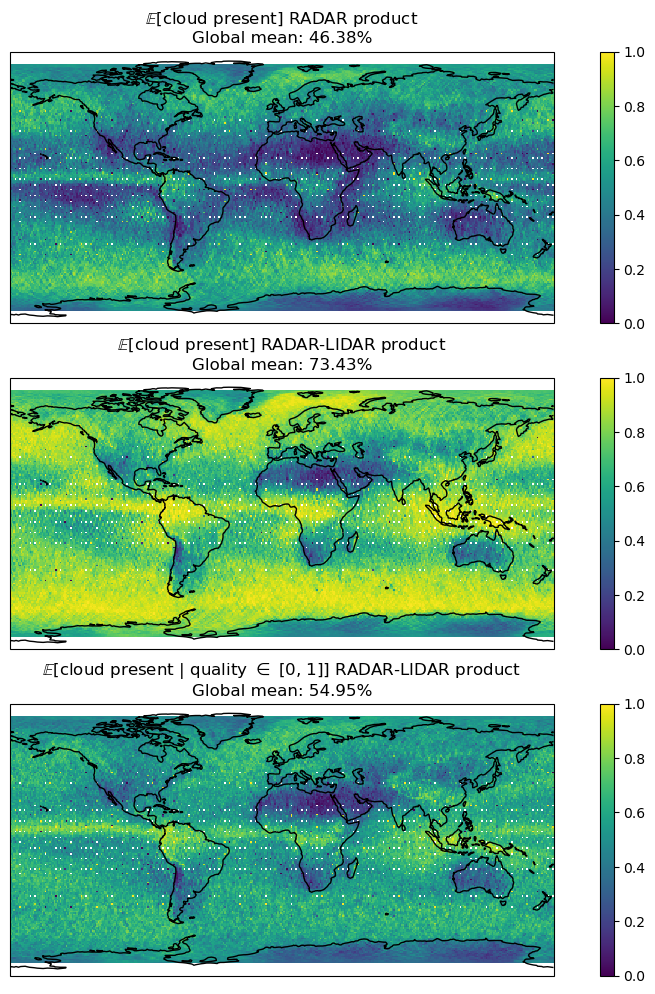

In [6]:
fig, axs = plt.subplots(ncols=1, nrows=3, figsize=(12,12), subplot_kw=dict(projection=ccrs.PlateCarree()))

ax = axs[0]


X, Y = np.meshgrid(lon_edges, lat_edges)

m = ax.pcolormesh(X, Y, average_ro.T, transform=ccrs.PlateCarree())

ax.set_global()
ax.coastlines()

fig.colorbar(m, ax=ax)

weights = np.isfinite(average_ro) * np.tile(np.cos(np.deg2rad((lat_edges[:1] + lat_edges[1:]) / 2)), (360, 1))
weights /= weights.sum()

ax.set_title(f'$\mathbb{{E}}$[cloud present] RADAR product\nGlobal mean: {np.nansum(average_ro * weights) *100 :.2f}%')

ax = axs[1]

m = ax.pcolormesh(X, Y, average_lr.T, transform=ccrs.PlateCarree())

ax.set_global()
ax.coastlines()

fig.colorbar(m, ax=ax)

weights = np.isfinite(average_lr) * np.tile(np.cos(np.deg2rad((lat_edges[:1] + lat_edges[1:]) / 2)), (360, 1))
weights /= weights.sum()

ax.set_title(f'$\mathbb{{E}}$[cloud present] RADAR-LIDAR product\nGlobal mean: {np.nansum(average_lr * weights) *100 :.2f}%')

ax = axs[2]

m = ax.pcolormesh(X, Y, average_lrq.T, transform=ccrs.PlateCarree())

ax.set_global()
ax.coastlines()

fig.colorbar(m, ax=ax)

weights = np.isfinite(average_lrq) * np.tile(np.cos(np.deg2rad((lat_edges[:1] + lat_edges[1:]) / 2)), (360, 1))
weights /= weights.sum()

ax.set_title(f'$\mathbb{{E}}$[cloud present | quality $\in$ [0, 1]] RADAR-LIDAR product\nGlobal mean: {np.nansum(average_lrq * weights) *100 :.2f}%')

plt.show()

For the second plot, where $\mathbb{E}[\text{cloud present}]$, there are quality values exceeding 1, which contradicts the official documentation.

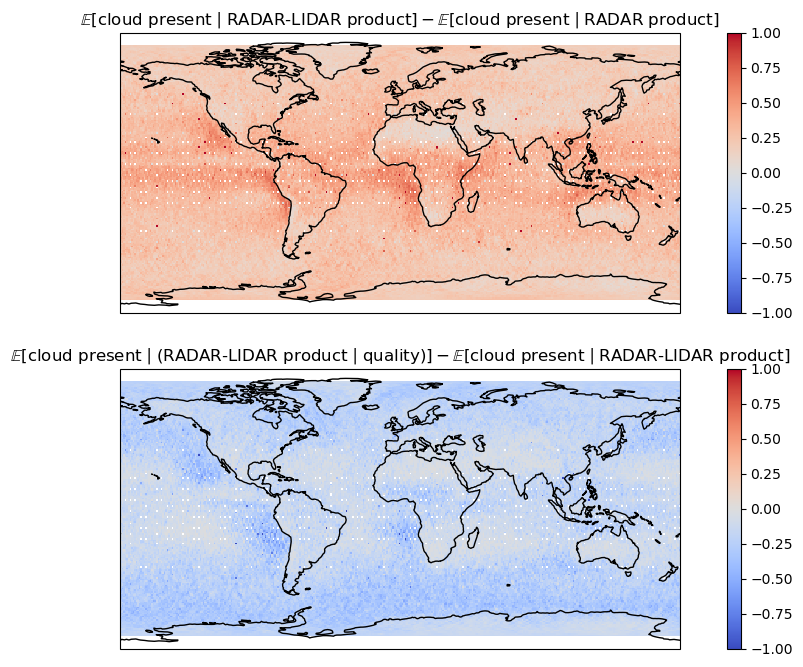

In [7]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(12,8), subplot_kw=dict(projection=ccrs.PlateCarree()))

ax = axs[0]


X, Y = np.meshgrid(lon_edges, lat_edges)

m = ax.pcolormesh(X, Y, average_lr.T - average_ro.T, transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='coolwarm')

ax.set_global()
ax.coastlines()

fig.colorbar(m, ax=ax)

ax.set_title(r'$\mathbb{{E}}[\text{cloud present} \mid \text{RADAR-LIDAR product}] - \mathbb{{E}}[\text{cloud present} \mid \text{RADAR product}]$')

ax = axs[1]

m = ax.pcolormesh(X, Y, average_lrq.T - average_lr.T, transform=ccrs.PlateCarree(), vmin=-1, vmax=1, cmap='coolwarm')

ax.set_global()
ax.coastlines()

fig.colorbar(m, ax=ax)

ax.set_title(r'$\mathbb{{E}}[\text{cloud present} \mid (\text{RADAR-LIDAR product} \mid \text{quality})] - \mathbb{{E}}[\text{cloud present} \mid \text{RADAR-LIDAR product}]$')

plt.show()

In [8]:
e_rolr = np.divide(
    arrays['acc_rolr'][:37081],
    arrays['counts_rolr'][:37081],
    out=np.full((37081, 125), np.nan),
    where=arrays['counts_rolr'][:37081] > 0
)

e_lrlrq = np.divide(
    arrays['acc_lrlrq'][:37081],
    arrays['counts_lrlrq'][:37081],
    out=np.full((37081, 125), np.nan),
    where=arrays['counts_lrlrq'][:37081] > 0
)

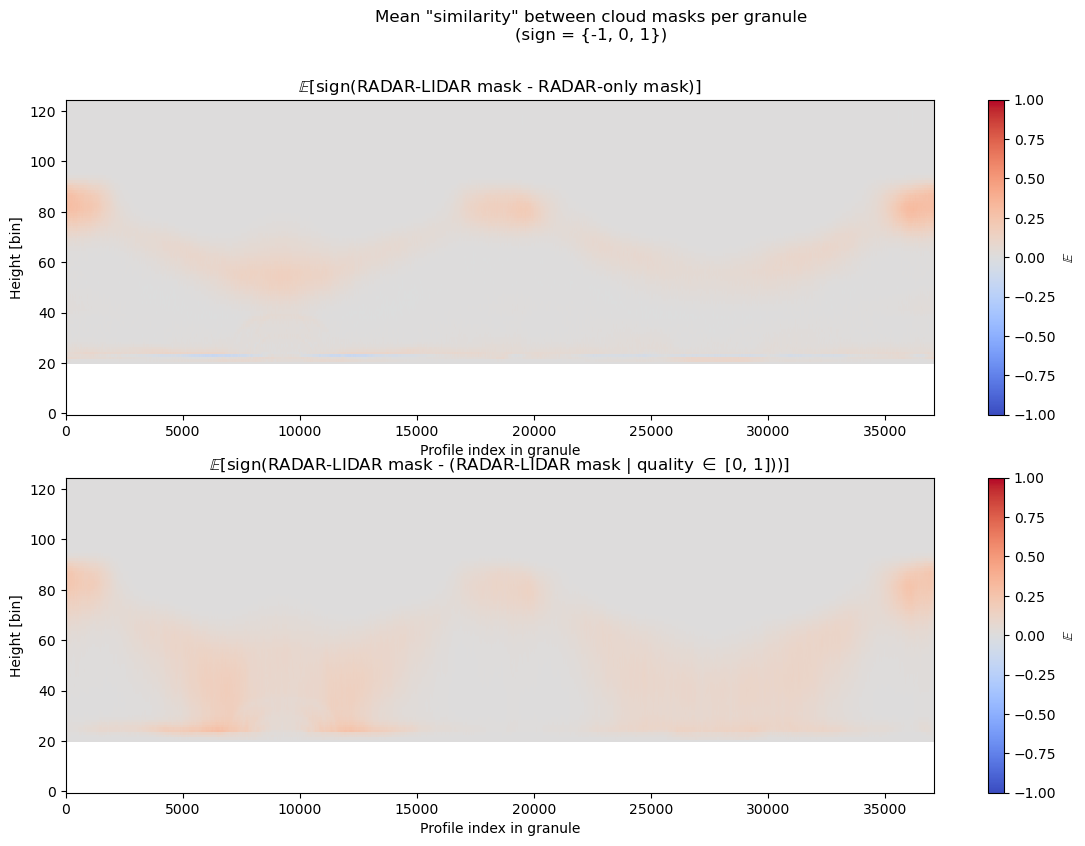

In [9]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 9))

X, Y = np.meshgrid(np.arange(37081), np.flip(np.arange(125)))

ax = axs[0]

m = ax.pcolormesh(X, Y, e_rolr.T[:37081], vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(m, ax=ax, label='$\mathbb{E}$')
ax.set_title('$\mathbb{E}$[sign(RADAR-LIDAR mask - RADAR-only mask)]')

ax = axs[1]

m = ax.pcolormesh(X, Y, e_lrlrq.T[:37081], vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(m, ax=ax, label='$\mathbb{E}$')
ax.set_title('$\mathbb{E}$[sign(RADAR-LIDAR mask - (RADAR-LIDAR mask | quality $\in$ [0, 1]))]')

for ax in axs:
    ax.set_xlabel('Profile index in granule')
    ax.set_ylabel('Height [bin]')

fig.suptitle('Mean "similarity" between cloud masks per granule\n(sign = {-1, 0, 1})')

plt.show()

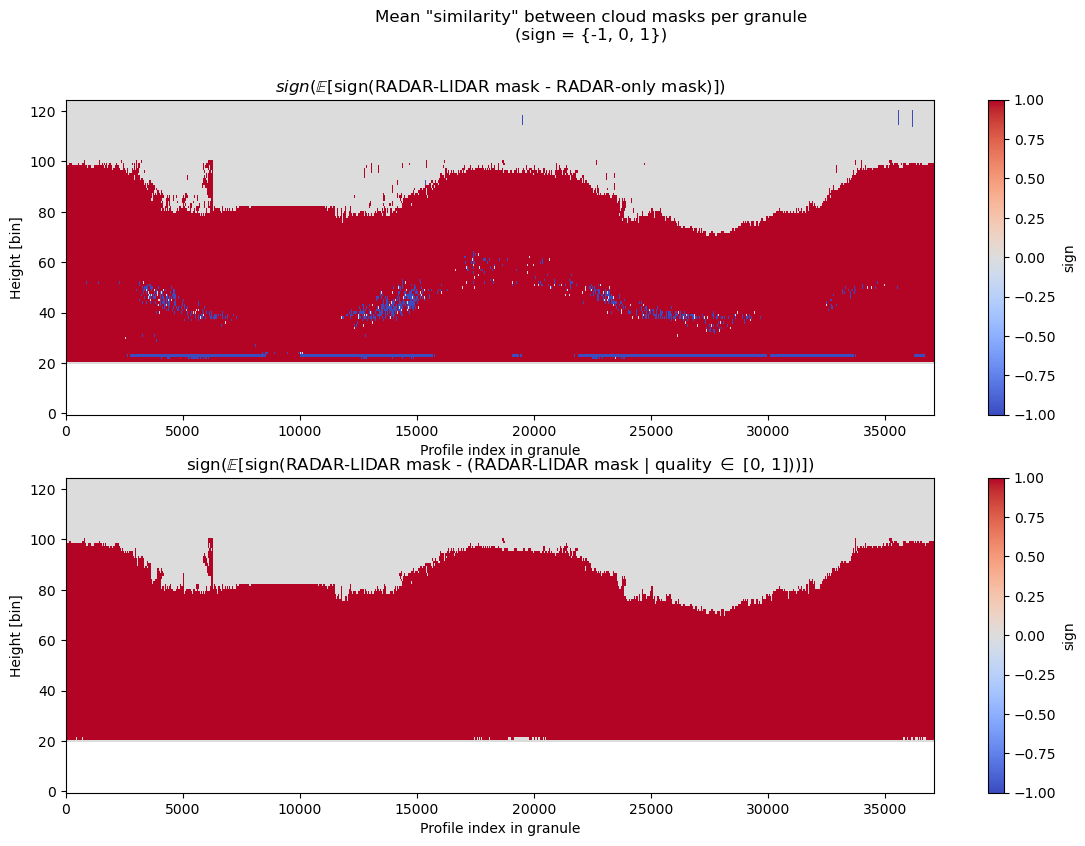

In [10]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 9))

X, Y = np.meshgrid(np.arange(37081), np.flip(np.arange(125)))

ax = axs[0]

m = ax.pcolormesh(X, Y, (np.sign(e_rolr) * (~np.isclose(e_rolr, 0))).T[:37081], vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(m, ax=ax, label='sign')
ax.set_title('$sign(\mathbb{E}$[sign(RADAR-LIDAR mask - RADAR-only mask)])')

ax = axs[1]

m = ax.pcolormesh(X, Y, (np.sign(e_lrlrq) * (~np.isclose(e_lrlrq, 0))).T[:37081], vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(m, ax=ax, label='sign')
ax.set_title('sign($\mathbb{E}$[sign(RADAR-LIDAR mask - (RADAR-LIDAR mask | quality $\in$ [0, 1]))])')

for ax in axs:
    ax.set_xlabel('Profile index in granule')
    ax.set_ylabel('Height [bin]')

fig.suptitle('Mean "similarity" between cloud masks per granule\n(sign = {-1, 0, 1})')

plt.show()

---

## First granule of 2010

In [11]:
with open('first_granule_2B-CLDCLASS_vs_2B-CLDCLASS-LIDAR_maps.pickle', 'rb') as handle:
    arrays = pickle.load(handle)

In [12]:
average_ro = np.divide(
    arrays['hits_ro'],
    arrays['counts_ro'],
    np.full((360, 180), np.nan),
    where=arrays['counts_ro'] > 0
)

average_lr = np.divide(
    arrays['hits_lr'],
    arrays['counts_lr'],
    np.full((360, 180), np.nan),
    where=arrays['counts_lr'] > 0
)

average_lrq = np.divide(
    arrays['hits_lrq'],
    arrays['counts_lrq'],
    np.full((360, 180), np.nan),
    where=arrays['counts_lrq'] > 0
)

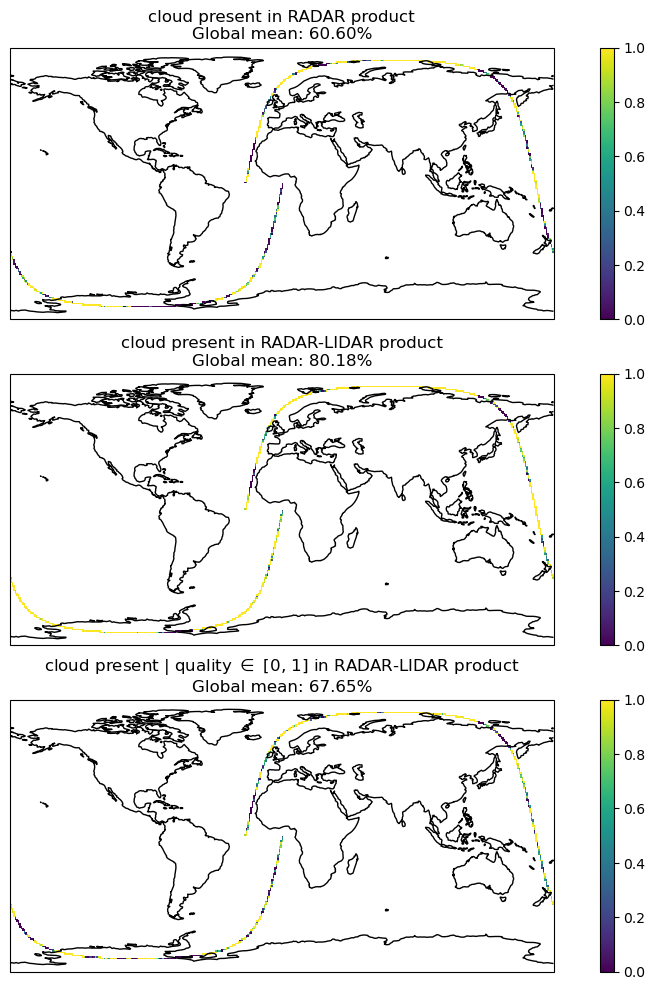

In [13]:
fig, axs = plt.subplots(ncols=1, nrows=3, figsize=(12,12), subplot_kw=dict(projection=ccrs.PlateCarree()))

ax = axs[0]


X, Y = np.meshgrid(lon_edges, lat_edges)

m = ax.pcolormesh(X, Y, average_ro.T, transform=ccrs.PlateCarree())

ax.set_global()
ax.coastlines()

fig.colorbar(m, ax=ax)

weights = np.isfinite(average_ro) * np.tile(np.cos(np.deg2rad((lat_edges[:1] + lat_edges[1:]) / 2)), (360, 1))
weights /= weights.sum()

ax.set_title(f'cloud present in RADAR product\nGlobal mean: {np.nansum(average_ro * weights) *100 :.2f}%')

ax = axs[1]

m = ax.pcolormesh(X, Y, average_lr.T, transform=ccrs.PlateCarree())

ax.set_global()
ax.coastlines()

fig.colorbar(m, ax=ax)

weights = np.isfinite(average_lr) * np.tile(np.cos(np.deg2rad((lat_edges[:1] + lat_edges[1:]) / 2)), (360, 1))
weights /= weights.sum()

ax.set_title(f'cloud present in RADAR-LIDAR product\nGlobal mean: {np.nansum(average_lr * weights) *100 :.2f}%')

ax = axs[2]

m = ax.pcolormesh(X, Y, average_lrq.T, transform=ccrs.PlateCarree())

ax.set_global()
ax.coastlines()

fig.colorbar(m, ax=ax)

weights = np.isfinite(average_lrq) * np.tile(np.cos(np.deg2rad((lat_edges[:1] + lat_edges[1:]) / 2)), (360, 1))
weights /= weights.sum()

ax.set_title(f'cloud present | quality $\in$ [0, 1] in RADAR-LIDAR product\nGlobal mean: {np.nansum(average_lrq * weights) *100 :.2f}%')

plt.show()

In [14]:
e_rolr = np.divide(
    arrays['acc_rolr'][:37081],
    arrays['counts_rolr'][:37081],
    out=np.full((37081, 125), np.nan),
    where=arrays['counts_rolr'][:37081] > 0
)

e_lrlrq = np.divide(
    arrays['acc_lrlrq'][:37081],
    arrays['counts_lrlrq'][:37081],
    out=np.full((37081, 125), np.nan),
    where=arrays['counts_lrlrq'][:37081] > 0
)

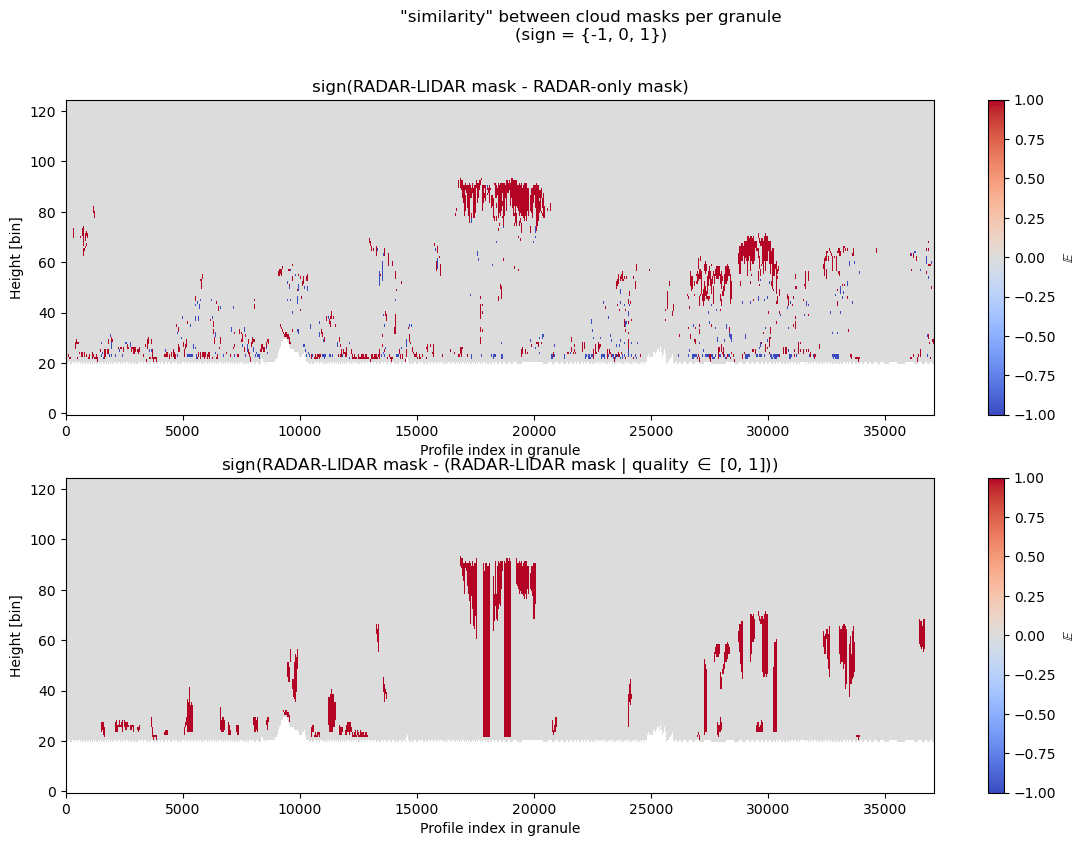

In [15]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 9))

X, Y = np.meshgrid(np.arange(37081), np.flip(np.arange(125)))

ax = axs[0]

m = ax.pcolormesh(X, Y, e_rolr.T, vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(m, ax=ax, label='$\mathbb{E}$')
ax.set_title('sign(RADAR-LIDAR mask - RADAR-only mask)')

ax = axs[1]

m = ax.pcolormesh(X, Y, e_lrlrq.T, vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(m, ax=ax, label='$\mathbb{E}$')
ax.set_title('sign(RADAR-LIDAR mask - (RADAR-LIDAR mask | quality $\in$ [0, 1]))')

for ax in axs:
    ax.set_xlabel('Profile index in granule')
    ax.set_ylabel('Height [bin]')

fig.suptitle('"similarity" between cloud masks per granule\n(sign = {-1, 0, 1})')

plt.show()

In [16]:
def layers_to_bins(ds: xr.Dataset, var: str, fill_value=0) -> xr.Dataset:
    a = xr.full_like(ds.height, fill_value, dtype=ds[var].dtype)
    a.attrs = {}

    start = xr.where(ds.cloud_layer_base == -99, np.nan, ds.cloud_layer_base) * 1e3
    end = xr.where(ds.cloud_layer_top == -99, np.nan, ds.cloud_layer_top) * 1e3

    quality = xr.where(ds.cloud_type_quality == -99, np.nan, 1)

    for l in ds.layers:
        condition = (start.sel(layers=l) <= ds.height) & (ds.height <= end.sel(layers=l))
        a = xr.where(condition, ds[var].sel(layers=l), a)
    
    a = xr.where(np.isnan(quality).all(dim='layers'), -1, a)

    
    return a

In [17]:
ds_ro = l2b_cldclass.open('/data/ro_vs_lr/radar/2010/017/2010017014344_19801_CS_2B-CLDCLASS_GRANULE_P1_R05_E03_F00.hdf')
ds_lr = l2b_cldclass_lidar.open('/data/ro_vs_lr/lidarradar/2010/017/2010017014344_19801_CS_2B-CLDCLASS-LIDAR_GRANULE_P1_R05_E03_F00.hdf')

ro_height_mask = xr.where(ds_ro.height <= xr.where(ds_ro.surface_elevation == -9999, 0, ds_ro.surface_elevation), np.nan, 1)
ro_mask_2D = ((ds_ro.cloud_class > 0) * (ds_ro.cloud_class_flag == 1)).astype(int) * ro_height_mask * xr.where(ds_ro.cloud_class < 0, np.nan, 1)

ds_lr['cloud_class_bins'] = (("rays", "bins"), layers_to_bins(ds_lr, "cloud_class").data)
lr_height_mask = xr.where(ds_lr.height <= xr.where(ds_lr.surface_elevation == -9999, 0, ds_lr.surface_elevation), np.nan, 1)
lr_mask_2D = (ds_lr.cloud_class_bins > 0).astype(int) * lr_height_mask * xr.where(ds_lr.cloud_class_bins < 0, np.nan, 1)

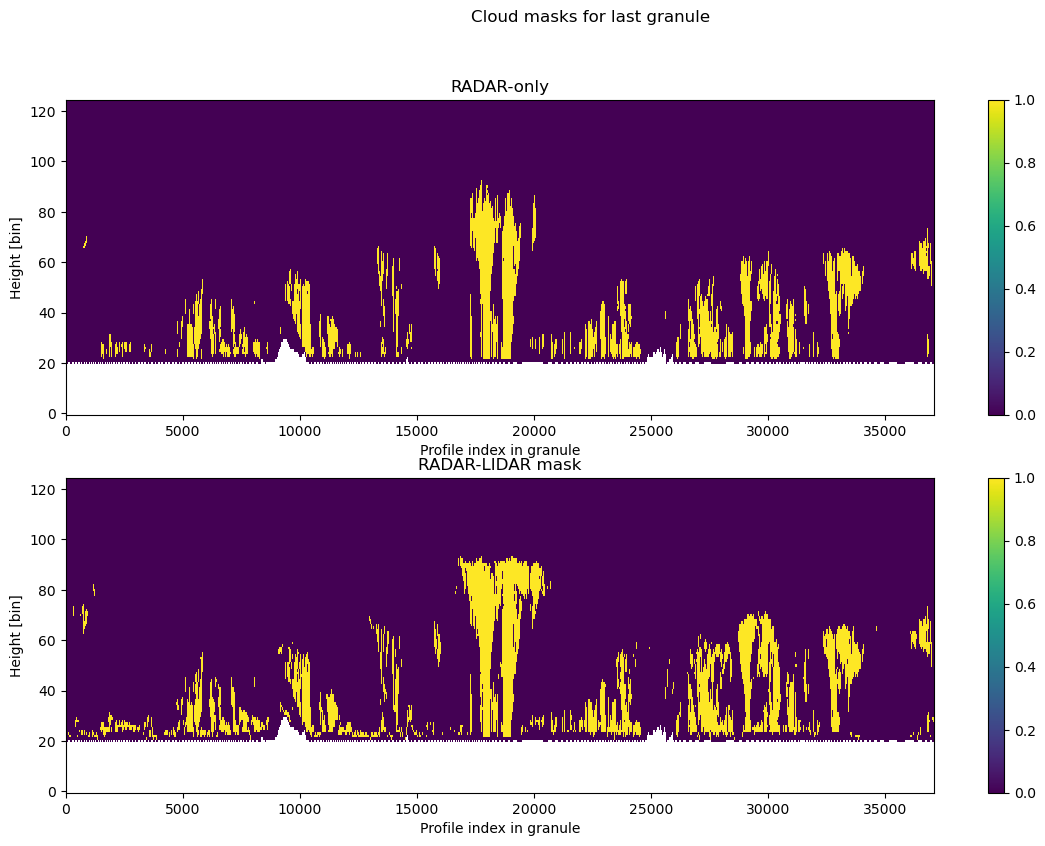

In [18]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 9))

X, Y = np.meshgrid(np.arange(37081), np.flip(np.arange(125)))

ax = axs[0]

m = ax.pcolormesh(X, Y, ro_mask_2D.data.T, vmin=0, vmax=1)
fig.colorbar(m, ax=ax)
ax.set_title('RADAR-only')

ax = axs[1]

m = ax.pcolormesh(X, Y, lr_mask_2D.data.T, vmin=0, vmax=1)
fig.colorbar(m, ax=ax)
ax.set_title('RADAR-LIDAR mask')

for ax in axs:
    ax.set_xlabel('Profile index in granule')
    ax.set_ylabel('Height [bin]')

fig.suptitle('Cloud masks for last granule')

plt.show()

---

## Last granule of 2010

In [19]:
with open('last_granule_2B-CLDCLASS_vs_2B-CLDCLASS-LIDAR_maps.pickle', 'rb') as handle:
    arrays = pickle.load(handle)

In [20]:
average_ro = np.divide(
    arrays['hits_ro'],
    arrays['counts_ro'],
    np.full((360, 180), np.nan),
    where=arrays['counts_ro'] > 0
)

average_lr = np.divide(
    arrays['hits_lr'],
    arrays['counts_lr'],
    np.full((360, 180), np.nan),
    where=arrays['counts_lr'] > 0
)

average_lrq = np.divide(
    arrays['hits_lrq'],
    arrays['counts_lrq'],
    np.full((360, 180), np.nan),
    where=arrays['counts_lrq'] > 0
)

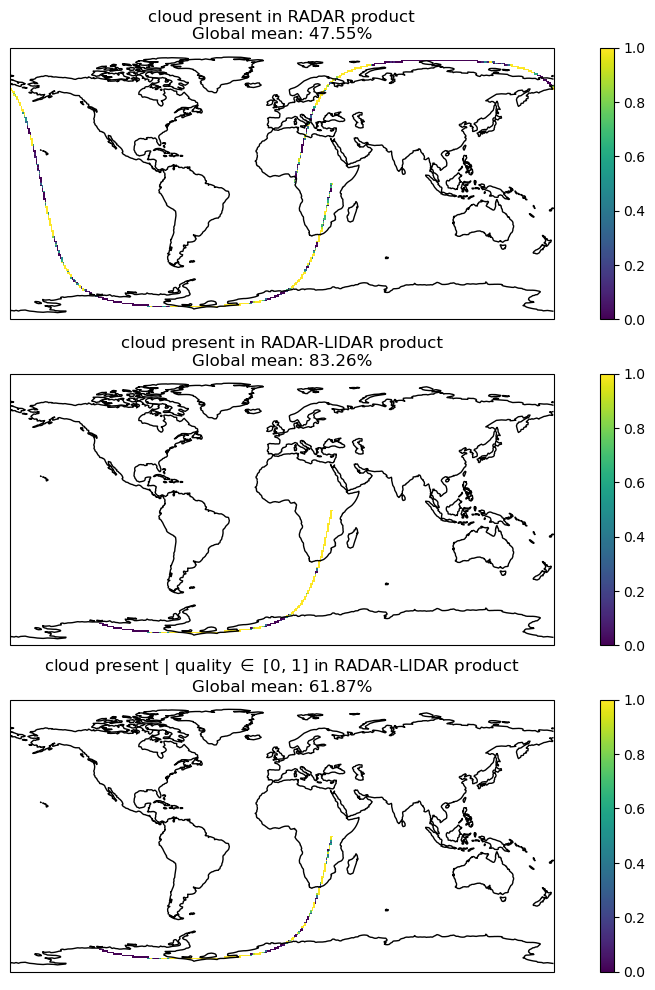

In [21]:
fig, axs = plt.subplots(ncols=1, nrows=3, figsize=(12,12), subplot_kw=dict(projection=ccrs.PlateCarree()))

ax = axs[0]


X, Y = np.meshgrid(lon_edges, lat_edges)

m = ax.pcolormesh(X, Y, average_ro.T, transform=ccrs.PlateCarree())

ax.set_global()
ax.coastlines()

fig.colorbar(m, ax=ax)

weights = np.isfinite(average_ro) * np.tile(np.cos(np.deg2rad((lat_edges[:1] + lat_edges[1:]) / 2)), (360, 1))
weights /= weights.sum()

ax.set_title(f'cloud present in RADAR product\nGlobal mean: {np.nansum(average_ro * weights) *100 :.2f}%')

ax = axs[1]

m = ax.pcolormesh(X, Y, average_lr.T, transform=ccrs.PlateCarree())

ax.set_global()
ax.coastlines()

fig.colorbar(m, ax=ax)

weights = np.isfinite(average_lr) * np.tile(np.cos(np.deg2rad((lat_edges[:1] + lat_edges[1:]) / 2)), (360, 1))
weights /= weights.sum()

ax.set_title(f'cloud present in RADAR-LIDAR product\nGlobal mean: {np.nansum(average_lr * weights) *100 :.2f}%')

ax = axs[2]

m = ax.pcolormesh(X, Y, average_lrq.T, transform=ccrs.PlateCarree())

ax.set_global()
ax.coastlines()

fig.colorbar(m, ax=ax)

weights = np.isfinite(average_lrq) * np.tile(np.cos(np.deg2rad((lat_edges[:1] + lat_edges[1:]) / 2)), (360, 1))
weights /= weights.sum()

ax.set_title(f'cloud present | quality $\in$ [0, 1] in RADAR-LIDAR product\nGlobal mean: {np.nansum(average_lrq * weights) *100 :.2f}%')

plt.show()

In [22]:
e_rolr = np.divide(
    arrays['acc_rolr'][:37081],
    arrays['counts_rolr'][:37081],
    out=np.full((37081, 125), np.nan),
    where=arrays['counts_rolr'][:37081] > 0
)

e_lrlrq = np.divide(
    arrays['acc_lrlrq'][:37081],
    arrays['counts_lrlrq'][:37081],
    out=np.full((37081, 125), np.nan),
    where=arrays['counts_lrlrq'][:37081] > 0
)

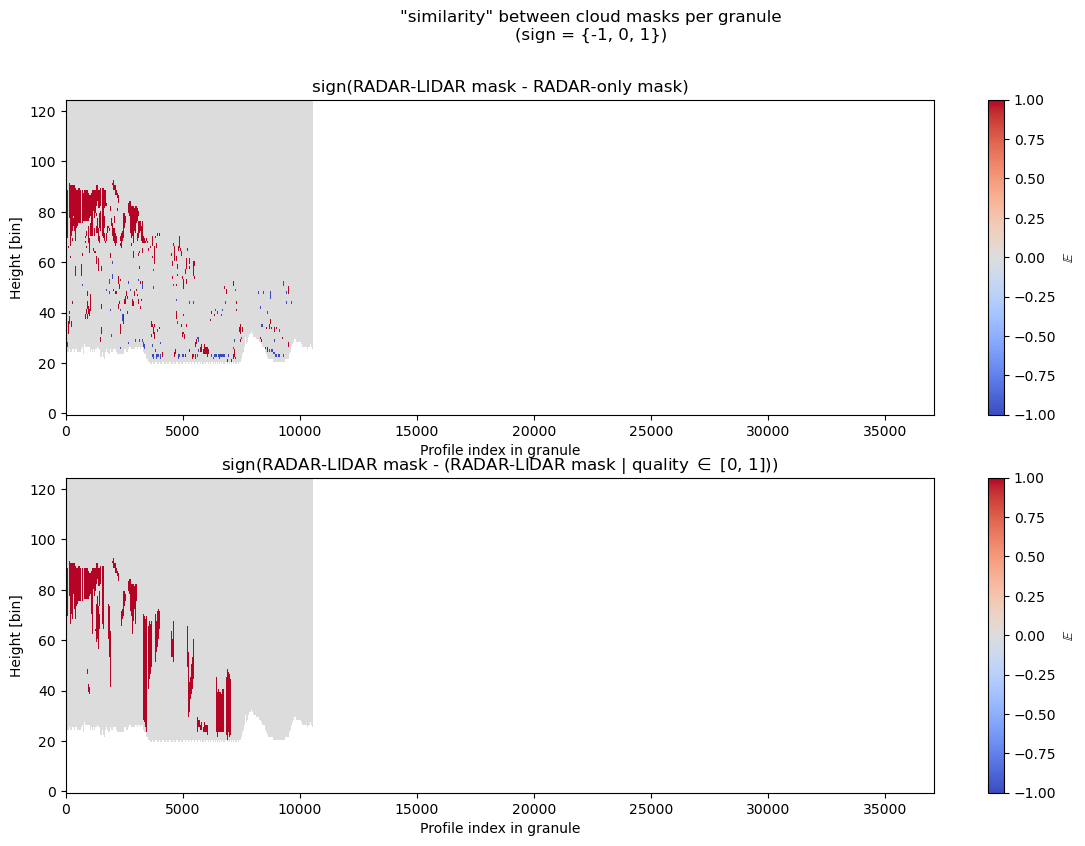

In [23]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 9))

X, Y = np.meshgrid(np.arange(37081), np.flip(np.arange(125)))

ax = axs[0]

m = ax.pcolormesh(X, Y, e_rolr.T, vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(m, ax=ax, label='$\mathbb{E}$')
ax.set_title('sign(RADAR-LIDAR mask - RADAR-only mask)')

ax = axs[1]

m = ax.pcolormesh(X, Y, e_lrlrq.T, vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(m, ax=ax, label='$\mathbb{E}$')
ax.set_title('sign(RADAR-LIDAR mask - (RADAR-LIDAR mask | quality $\in$ [0, 1]))')

for ax in axs:
    ax.set_xlabel('Profile index in granule')
    ax.set_ylabel('Height [bin]')

fig.suptitle('"similarity" between cloud masks per granule\n(sign = {-1, 0, 1})')

plt.show()

In [24]:
ds_ro = l2b_cldclass.open('/data/ro_vs_lr/radar/2010/365/2010365233151_24882_CS_2B-CLDCLASS_GRANULE_P1_R05_E03_F00.hdf')
ds_lr = l2b_cldclass_lidar.open('/data/ro_vs_lr/lidarradar/2010/365/2010365233151_24882_CS_2B-CLDCLASS-LIDAR_GRANULE_P1_R05_E03_F00.hdf')

ro_height_mask = xr.where(ds_ro.height <= xr.where(ds_ro.surface_elevation == -9999, 0, ds_ro.surface_elevation), np.nan, 1)
ro_mask_2D = ((ds_ro.cloud_class > 0) * (ds_ro.cloud_class_flag == 1)).astype(int) * ro_height_mask * xr.where(ds_ro.cloud_class < 0, np.nan, 1)

ds_lr['cloud_class_bins'] = (("rays", "bins"), layers_to_bins(ds_lr, "cloud_class").data)
lr_height_mask = xr.where(ds_lr.height <= xr.where(ds_lr.surface_elevation == -9999, 0, ds_lr.surface_elevation), np.nan, 1)
lr_mask_2D = (ds_lr.cloud_class_bins > 0).astype(int) * lr_height_mask * xr.where(ds_lr.cloud_class_bins < 0, np.nan, 1)

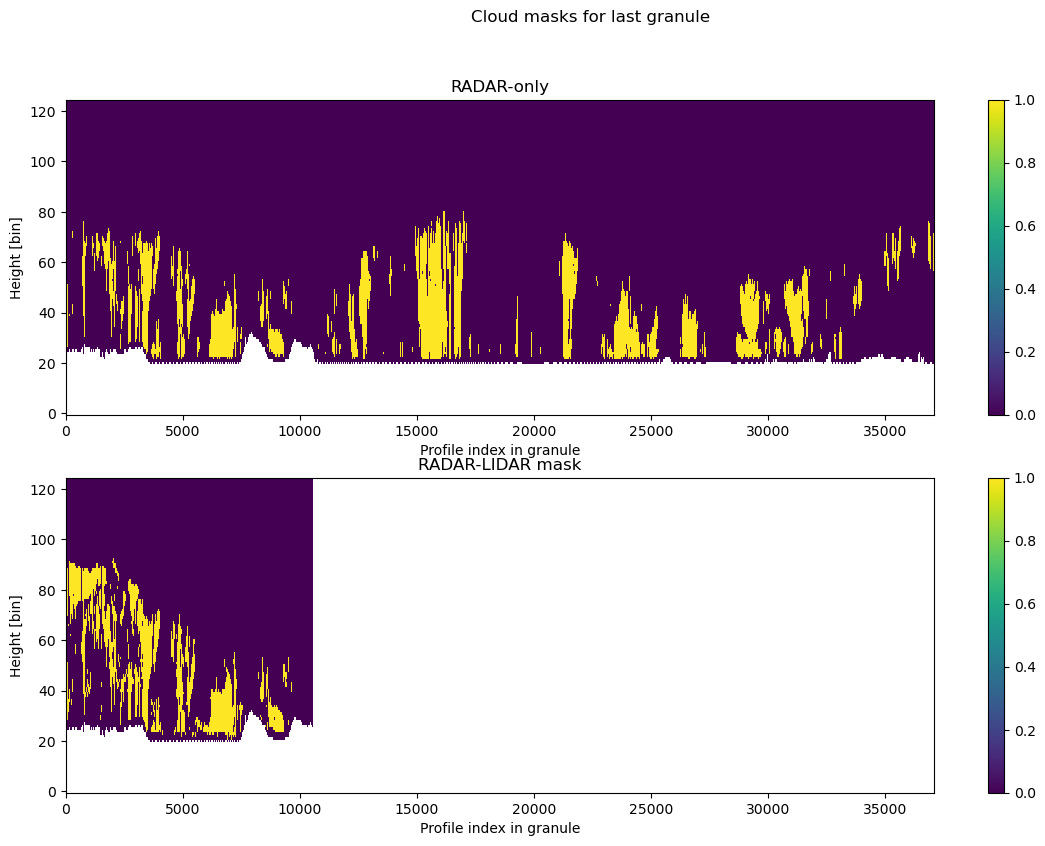

In [25]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 9))

X, Y = np.meshgrid(np.arange(37081), np.flip(np.arange(125)))

ax = axs[0]

m = ax.pcolormesh(X, Y, ro_mask_2D.data.T, vmin=0, vmax=1)
fig.colorbar(m, ax=ax)
ax.set_title('RADAR-only')

ax = axs[1]

m = ax.pcolormesh(X, Y, lr_mask_2D.data.T, vmin=0, vmax=1)
fig.colorbar(m, ax=ax)
ax.set_title('RADAR-LIDAR mask')

for ax in axs:
    ax.set_xlabel('Profile index in granule')
    ax.set_ylabel('Height [bin]')

fig.suptitle('Cloud masks for last granule')

plt.show()